# Movie Rating Analysis

## Complete Project Workflow

Understand Dataset -> Import Libraries -> Load Dataset -> Understand Dataset -> Check Missing Values -> Remove Duplicates -> Data Cleaning -> Exploratory Data Analysis -> Analyze Ratings -> Analyze Genres -> Analyze Years -> Analyze Runtime -> Analyze Votes -> Analyze Revenue -> Analyze Metascore -> Create Visualization -> Generate Insights

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv("IMDB-Movie-Data.csv")

## View Dataset

In [4]:
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [5]:
df.tail()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


In [6]:
df.shape

(1000, 12)

In [7]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')

## Understand the Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [9]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


In [10]:
df.dtypes

Rank                    int64
Title                  object
Genre                  object
Description            object
Director               object
Actors                 object
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object

## Check Missing Values

In [11]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [12]:
(df.isnull().sum() / len(df)) * 100

Rank                   0.0
Title                  0.0
Genre                  0.0
Description            0.0
Director               0.0
Actors                 0.0
Year                   0.0
Runtime (Minutes)      0.0
Rating                 0.0
Votes                  0.0
Revenue (Millions)    12.8
Metascore              6.4
dtype: float64

## Check Duplicates

In [13]:
df.duplicated().sum()

0

In [14]:
df = df.drop_duplicates()

## Clean Numeric Columns

In [15]:
df["Revenue (Millions)"] = pd.to_numeric(
    df["Revenue (Millions)"],
    errors="coerce"
)

In [16]:
df["Metascore"] = pd.to_numeric(
    df["Metascore"],
    errors="coerce"
)

In [17]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [18]:
df = df.dropna(subset=["Rating", "Genre", "Year"])

## Basic Rating Analysis

In [19]:
average_rating = df["Rating"].mean()

print("Average Movie Rating:", round(average_rating, 2))

Average Movie Rating: 6.72


In [20]:
df["Rating"].max()

9.0

In [21]:
df["Rating"].min()

1.9

## Find Top 10 Rated Movies

In [22]:
top_movies = df.sort_values(
    by="Rating",
    ascending=False
).head(10)

top_movies[["Title", "Rating"]]

,Title,Rating
54,The Dark Knight,9.0
80,Inception,8.8
117,Dangal,8.8
36,Interstellar,8.6
96,Kimi no na wa,8.6
249,The Intouchables,8.6
133,Whiplash,8.5
64,The Prestige,8.5
99,The Departed,8.5
991,Taare Zameen Par,8.5


## Find Bottom 10 Rated Movies

In [23]:
bottom_movies = df.sort_values(
    by="Rating",
    ascending=True
).head(10)

bottom_movies[["Title", "Rating"]]

,Title,Rating
829,Disaster Movie,1.9
42,Don't Fuck in the Woods,2.7
871,Dragonball Evolution,2.7
647,Tall Men,3.2
968,Wrecker,3.5
890,The Intent,3.5
49,The Last Face,3.7
269,Satanic,3.7
525,Birth of the Dragon,3.9
401,The Black Room,3.9


# Visualization

## Rating Distribution

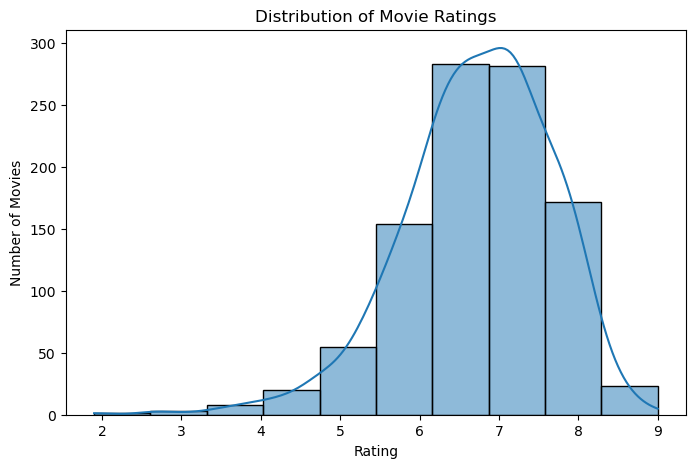

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=10,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()


## Genre Analysis

In [34]:
df["Genre"].head()

0     Action,Adventure,Sci-Fi
1    Adventure,Mystery,Sci-Fi
2             Horror,Thriller
3     Animation,Comedy,Family
4    Action,Adventure,Fantasy
Name: Genre, dtype: object

In [35]:
genre_df = df.assign(
    Genre=df["Genre"].str.split(",")
).explode("Genre")

In [36]:
genre_df["Genre"] = genre_df["Genre"].str.strip()

In [37]:
genre_df["Genre"].value_counts()


Genre
Drama        513
Action       303
Comedy       279
Adventure    259
Thriller     195
Crime        150
Romance      141
Sci-Fi       120
Horror       119
Mystery      106
Fantasy      101
Biography     81
Family        51
Animation     49
History       29
Sport         18
Music         16
War           13
Western        7
Musical        5
Name: count, dtype: int64

## Most Common Genres

In [29]:
genre_counts = genre_df["Genre"].value_counts()

genre_counts.head(10)

Genre
Drama        513
Action       303
Comedy       279
Adventure    259
Thriller     195
Crime        150
Romance      141
Sci-Fi       120
Horror       119
Mystery      106
Name: count, dtype: int64

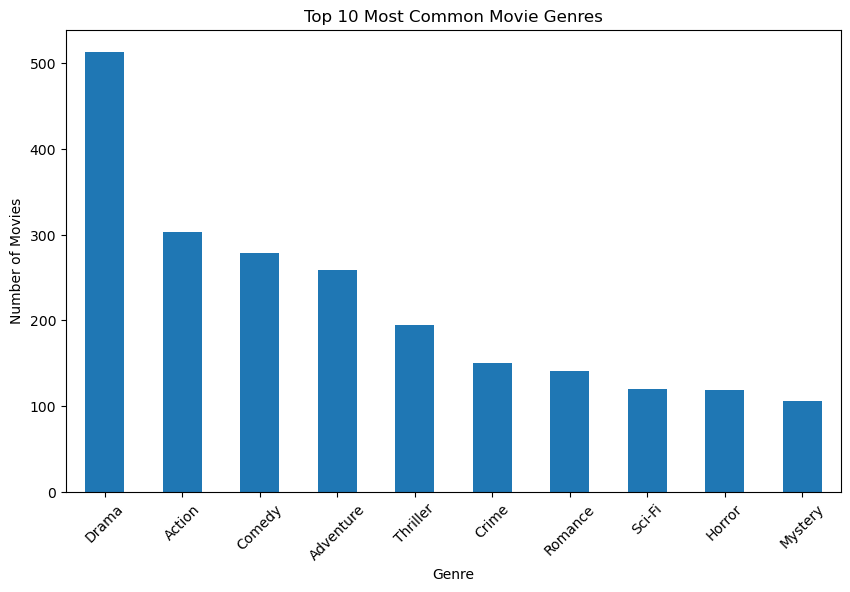

In [30]:
plt.figure(figsize=(10,6))

genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Common Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

## Average Rating by Genre

In [31]:
genre_rating = genre_df.groupby("Genre")["Rating"].mean().sort_values(
    ascending=False
)

genre_rating

Genre
War          7.353846
Animation    7.324490
Biography    7.290123
History      7.127586
Music        7.075000
Sport        7.011111
Drama        6.953801
Musical      6.940000
Mystery      6.886792
Crime        6.786667
Adventure    6.772201
Western      6.771429
Sci-Fi       6.716667
Romance      6.685816
Family       6.684314
Comedy       6.647670
Action       6.614521
Thriller     6.593333
Fantasy      6.548515
Horror       6.089916
Name: Rating, dtype: float64

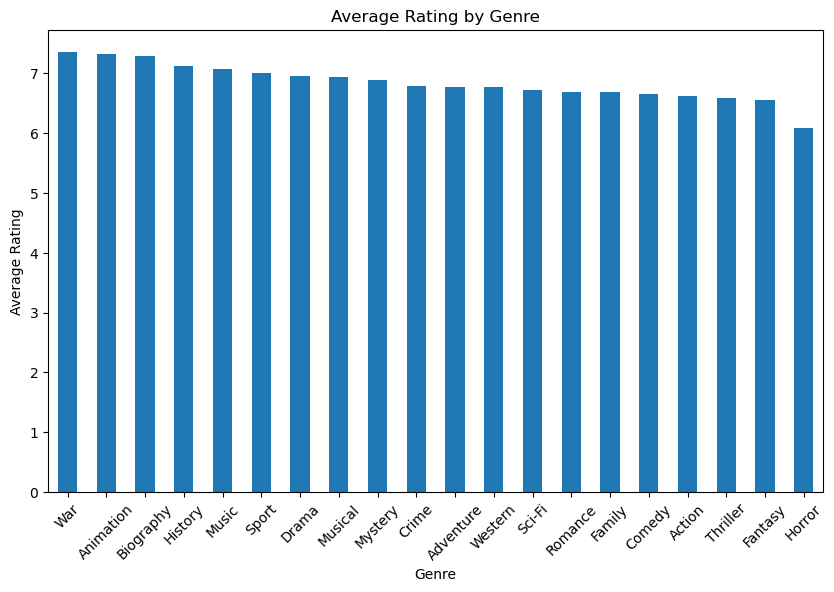

In [32]:
plt.figure(figsize=(10,6))

genre_rating.plot(kind="bar")

plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

## Year Analysis

In [38]:
movies_per_year = df["Year"].value_counts().sort_index()

movies_per_year

Year
2006     44
2007     53
2008     52
2009     51
2010     60
2011     63
2012     64
2013     91
2014     98
2015    127
2016    297
Name: count, dtype: int64

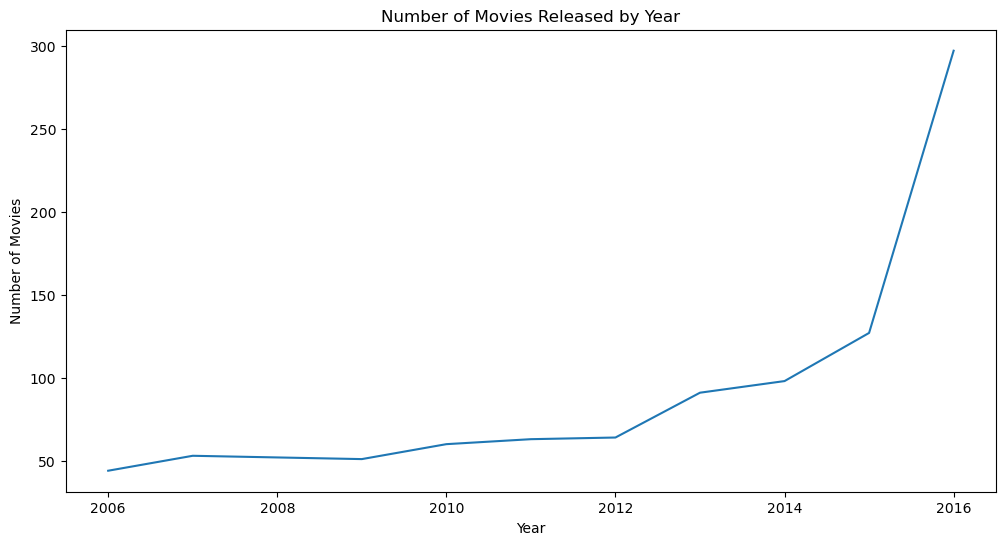

In [39]:
plt.figure(figsize=(12,6))

movies_per_year.plot()

plt.title("Number of Movies Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()


## Average Rating by Year

In [40]:
year_rating = df.groupby("Year")["Rating"].mean()

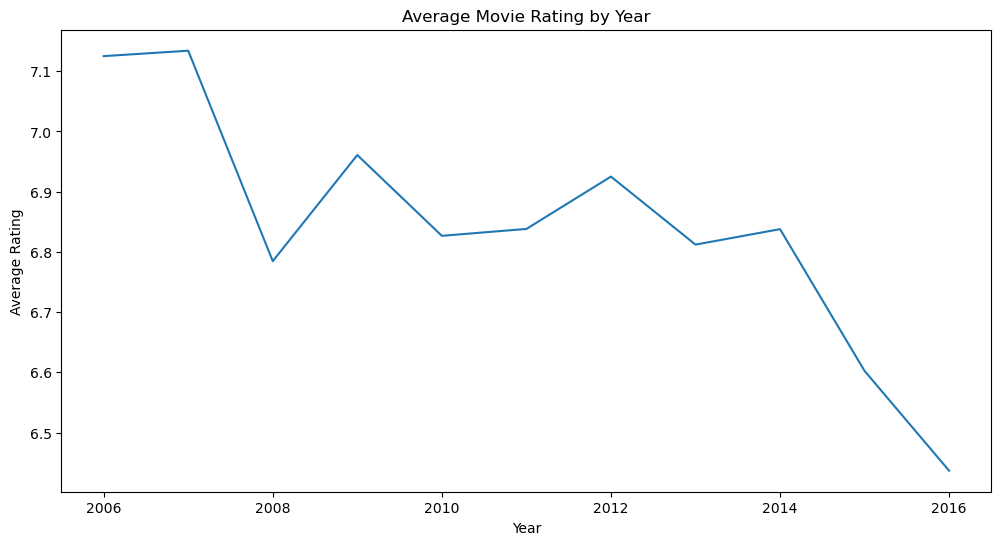

In [42]:
plt.figure(figsize=(12,6))

year_rating.plot()

plt.title("Average Movie Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

## Runtime Analysis

In [43]:
df["Runtime (Minutes)"].mean()

113.172

In [44]:
df.loc[
    df["Runtime (Minutes)"].idxmax(),
    ["Title", "Runtime (Minutes)"]
]

Title                Grindhouse
Runtime (Minutes)           191
Name: 828, dtype: object

In [46]:
df.loc[
    df["Runtime (Minutes)"].idxmin(),
    ["Title", "Runtime (Minutes)"]
]

Title                Ma vie de Courgette
Runtime (Minutes)                     66
Name: 793, dtype: object

## Runtime vs Rating

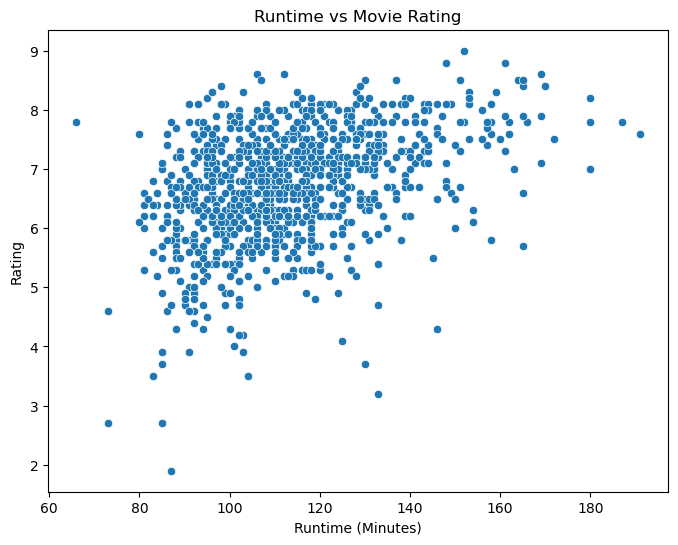

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Runtime (Minutes)",
    y="Rating"
)

plt.title("Runtime vs Movie Rating")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Rating")

plt.show()

## Votes Analysis

In [48]:
most_voted = df.sort_values(
    by="Votes",
    ascending=False
).head(10)

most_voted[["Title", "Votes", "Rating"]]

,Title,Votes,Rating
54,The Dark Knight,1791916,9.0
80,Inception,1583625,8.8
124,The Dark Knight Rises,1222645,8.5
36,Interstellar,1047747,8.6
76,The Avengers,1045588,8.1
144,Django Unchained,1039115,8.4
77,Inglourious Basterds,959065,8.3
99,The Departed,937414,8.5
87,Avatar,935408,7.8
64,The Prestige,913152,8.5


## Votes vs Rating

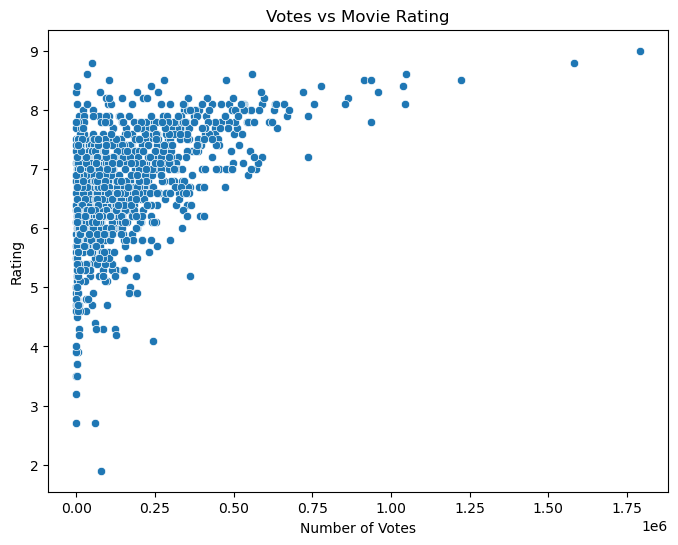

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Rating"
)

plt.title("Votes vs Movie Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")

plt.show()

## Revenue Analysis

In [50]:
top_revenue = df.sort_values(
    by="Revenue (Millions)",
    ascending=False
).head(10)

top_revenue[
    ["Title", "Revenue (Millions)", "Rating"]
]

,Title,Revenue (Millions),Rating
50,Star Wars: Episode VII - The Force Awakens,936.63,8.1
87,Avatar,760.51,7.8
85,Jurassic World,652.18,7.0
76,The Avengers,623.28,8.1
54,The Dark Knight,533.32,9.0
12,Rogue One,532.17,7.9
119,Finding Dory,486.29,7.4
94,Avengers: Age of Ultron,458.99,7.4
124,The Dark Knight Rises,448.13,8.5
578,The Hunger Games: Catching Fire,424.65,7.6


<Figure size 1000x600 with 0 Axes>

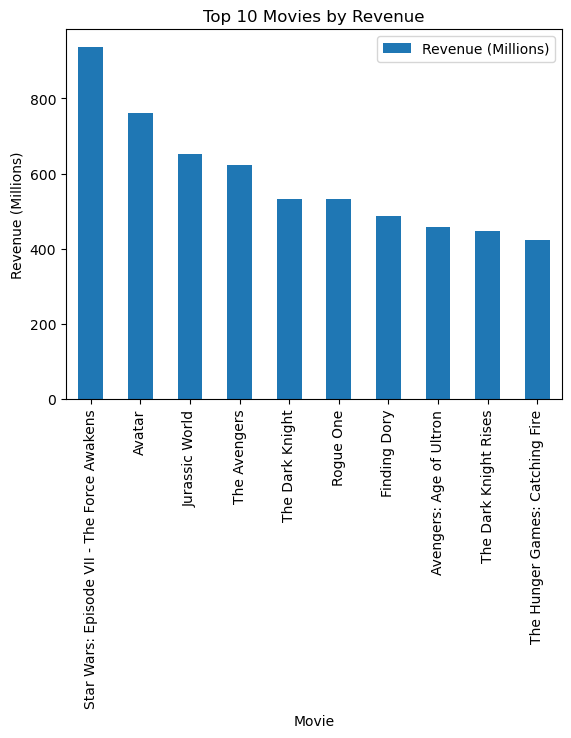

In [51]:
plt.figure(figsize=(10,6))

top_revenue.plot(
    x="Title",
    y="Revenue (Millions)",
    kind="bar"
)

plt.title("Top 10 Movies by Revenue")
plt.xlabel("Movie")
plt.ylabel("Revenue (Millions)")

plt.xticks(rotation=90)

plt.show()

## Revenue vs Rating

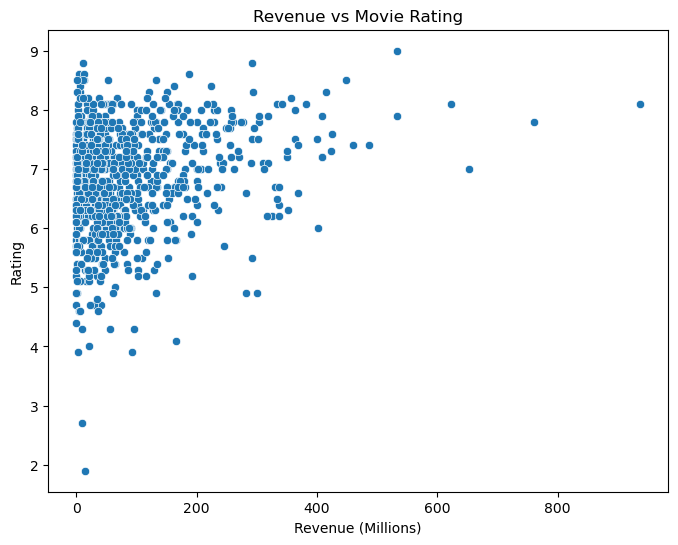

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Revenue (Millions)",
    y="Rating"
)

plt.title("Revenue vs Movie Rating")
plt.xlabel("Revenue (Millions)")
plt.ylabel("Rating")

plt.show()

## Metascore vs IMDb Rating

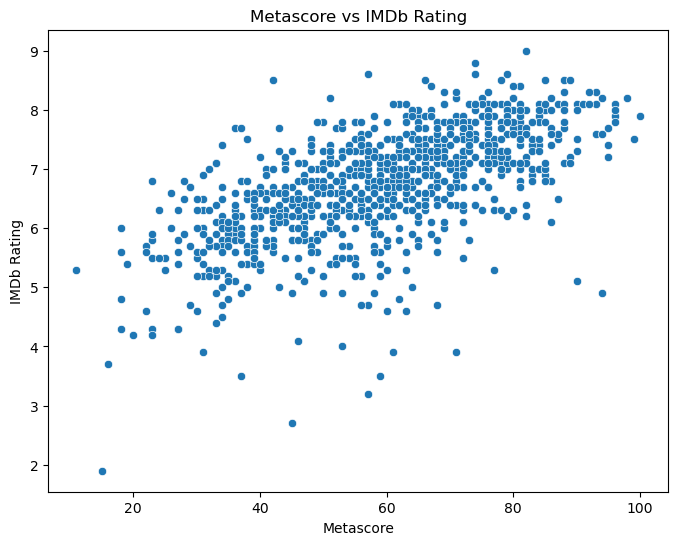

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Metascore",
    y="Rating"
)

plt.title("Metascore vs IMDb Rating")
plt.xlabel("Metascore")
plt.ylabel("IMDb Rating")

plt.show()


## Correlation Analysis

In [54]:
numeric_columns = [
    "Year",
    "Runtime (Minutes)",
    "Rating",
    "Votes",
    "Revenue (Millions)",
    "Metascore"
]

correlation = df[numeric_columns].corr()

correlation

,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
Year,1.000000,-0.164900,-0.211219,-0.411904,-0.126790,-0.079305
Runtime (Minutes),-0.164900,1.000000,0.392214,0.407062,0.267953,0.211978
Rating,-0.211219,0.392214,1.000000,0.511537,0.217654,0.631897
Votes,-0.411904,0.407062,0.511537,1.000000,0.639661,0.325684
Revenue (Millions),-0.126790,0.267953,0.217654,0.639661,1.000000,0.142397
Metascore,-0.079305,0.211978,0.631897,0.325684,0.142397,1.000000


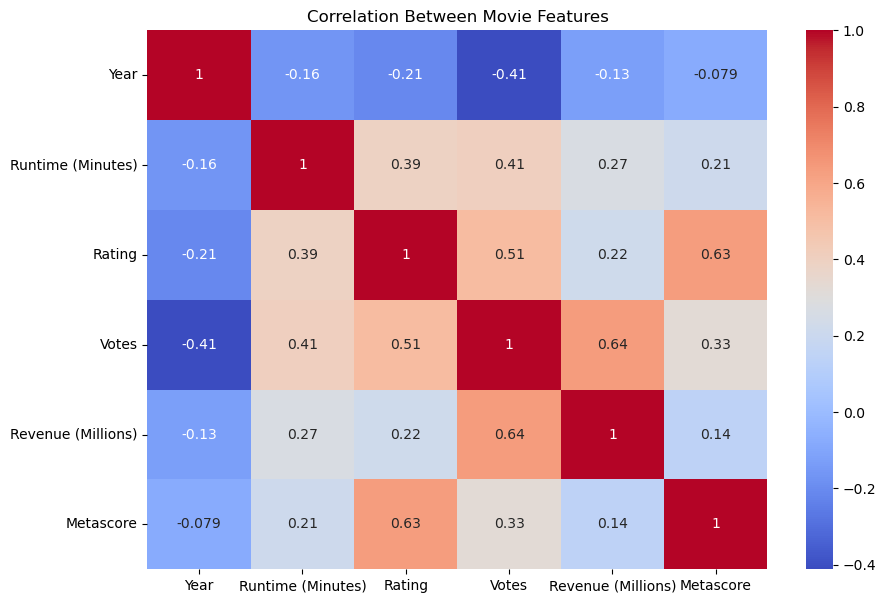

In [55]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Movie Features")

plt.show()

KEY INSIGHTS

1. The average IMDb rating of the movies in the dataset is approximately X.

2. Drama is one of the most frequently occurring genres in the dataset.

3. The average rating varies across different movie genres.

4. The number of movies released varies considerably across different years.

5. Movie runtime does not show a strong visible relationship with IMDb rating.

6. Movies with a large number of votes are generally more popular among IMDb users.

7. Revenue varies significantly among movies.

8. IMDb ratings and Metascores show a positive/negative/weak relationship based on the correlation analysis.